In [ ]:
import pandas as pd
import numpy as np


df_clean = pd.read_csv("../data/processed/HHS_Clean_Dataset.csv")

df_clean["Date"] = pd.to_datetime(df_clean["Date"])

df_clean = df_clean.sort_values("Date")

df_clean = df_clean.set_index("Date")

print(df_clean.index.day_name().value_counts().sort_index())

Date
Friday         2
Monday       142
Sunday       127
Thursday     145
Tuesday      146
Wednesday    144
Name: count, dtype: int64


In [9]:
'''ARIMA MODEL '''
series = df_clean["Children in HHS Care"]

train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

# MODEL building
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

# FORECASTING 
forecast = model_fit.forecast(steps=len(test))

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     Children in HHS Care   No. Observations:                  564
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -3608.023
Date:                  Wed, 05 Aug 2026   AIC                           7222.046
Time:                          13:26:57   BIC                           7235.045
Sample:                               0   HQIC                          7227.121
                                  - 564                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0345      0.238      0.145      0.885      -0.433       0.502
ma.L1          0.1494      0.236      0.634      0.526      -0.313       0.611
sigma2      2.152e+04    712.920    

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
'''Evaluation of the model'''
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(mean_squared_error(test, forecast))

print(mae)
print(rmse)

197.55578177092167
241.43059467638327


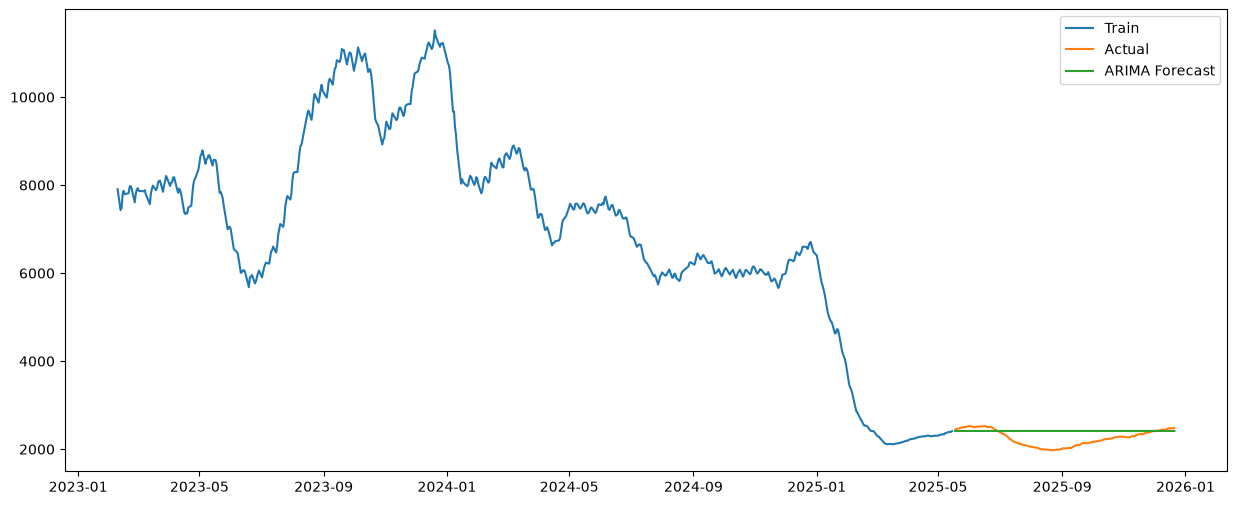

In [11]:
# ploting
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(train.index, train, label="Train")

plt.plot(test.index, test, label="Actual")

plt.plot(test.index, forecast, label="ARIMA Forecast")

plt.legend()

plt.show()

In [12]:
forecast = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape * 100)

MAE : 197.55578177092167
RMSE: 241.43059467638327
MAPE: 9.310805646181608


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [13]:
comparison = pd.DataFrame({
    "Actual": test,
    "Predicted": forecast
})

print(comparison.head())

                     Actual  Predicted
2025-05-18 00:00:00  2437.0        NaN
2025-05-19 00:00:00  2457.0        NaN
2025-05-21 00:00:00  2467.0        NaN
2025-05-22 00:00:00  2473.0        NaN
2025-05-27 00:00:00  2504.0        NaN


In [14]:
print(type(forecast))
print(forecast.head())
print(forecast.tail())

print(test.index[:5])
print(forecast.index[:5])

<class 'pandas.core.series.Series'>
564    2412.948999
565    2413.050813
566    2413.054328
567    2413.054450
568    2413.054454
Name: predicted_mean, dtype: float64
701    2413.054454
702    2413.054454
703    2413.054454
704    2413.054454
705    2413.054454
Name: predicted_mean, dtype: float64
DatetimeIndex(['2025-05-18', '2025-05-19', '2025-05-21', '2025-05-22',
               '2025-05-27'],
              dtype='datetime64[ns]', name='Date', freq=None)
RangeIndex(start=564, stop=569, step=1)


In [15]:
forecast = pd.Series(
    forecast.values,
    index=test.index,
    name="Predicted"
)

comparison = pd.DataFrame({
    "Actual": test,
    "Predicted": forecast
})

comparison.head()

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

mae = mean_absolute_error(
    test.values,
    forecast.values
)

rmse = np.sqrt(
    mean_squared_error(
        test.values,
        forecast.values
    )
)

mape = mean_absolute_percentage_error(
    test.values,
    forecast.values
)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape * 100)

MAE : 197.55578177092167
RMSE: 241.43059467638327
MAPE: 9.310805646181608


<Figure size 1200x500 with 0 Axes>

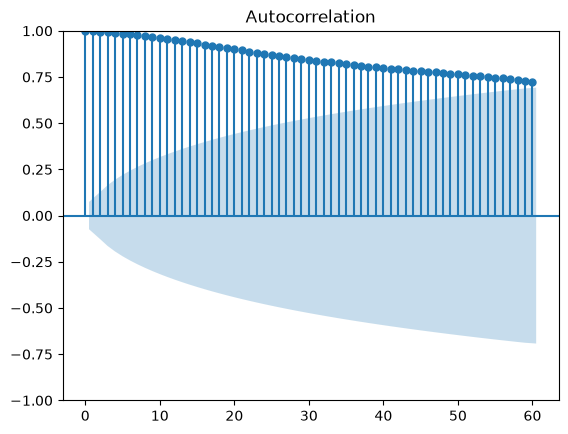

In [16]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plot_acf(df_clean["Children in HHS Care"], lags=60)
plt.show()